# Notebook 02 — NLP Text Preprocessing

## Overview
This notebook demonstrates **Technique 1: NLP Text Preprocessing** — the foundational step that transforms raw, noisy text into clean, structured input suitable for machine learning models.

Raw text contains noise such as:
- Special characters and punctuation
- Numbers and symbols
- Common words ('the', 'is', 'a') that carry no meaning — called **stopwords**
- Mixed capitalisation

## Preprocessing Steps Applied
1. **Combine text fields** — merge genres + keywords + plot overview + cast into one rich text per movie
2. **Lowercase** — normalise all text
3. **Remove punctuation and special characters** — using regex
4. **Remove stopwords** — using NLTK's English stopword list
5. **Tokenise** — split into individual words

## Why This Matters for the Report
Preprocessing directly improves embedding quality. Without it, words like 'The' and 'the' are treated as different, and common words like 'is' and 'a' would dominate the vector space with no useful information.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
from src.preprocess import preprocess_pipeline, clean_text

plt.style.use('dark_background')
nltk.download('stopwords', quiet=True)
print('Setup complete.')

Setup complete.


## 1. Run the Full Preprocessing Pipeline

The `preprocess_pipeline()` function in `src/preprocess.py` executes all steps automatically:
- Loads `tmdb_5000_movies.csv` and `tmdb_5000_credits.csv`
- Parses JSON-encoded genre, keyword, and cast fields using `ast.literal_eval`
- Combines all text fields into one `combined_text` column
- Applies `clean_text()` to produce the final `clean_text` column
- Saves result to `data/processed/movies_processed.csv`

In [2]:
df = preprocess_pipeline()
print(f'Processed {len(df)} movies.')
print(f'Columns: {list(df.columns)}')
df[['title', 'genres', 'clean_text']].head(5)

Detected TMDB 5000 dataset.
Loaded 4803 movies. Cleaning text...



leaning: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 4803/4803 [00:00<00:00, 53760.64it/s]

Saved to D:\Project\Content-Recommendation-System-with-NLP-Explanation\notebooks\..\src\..\data\processed\movies_processed.csv
Processed 4803 movies.
Columns: ['movieid', 'title', 'genres', 'combined_text', 'clean_text']


,title,genres,clean_text
0,Avatar,Action Adventure Fantasy Science Fiction,action adventure fantasy science fiction cultu...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,adventure fantasy action ocean drug abuse exot...
2,Spectre,Action Adventure Crime,action adventure crime spy based novel secret ...
3,The Dark Knight Rises,Action Crime Drama Thriller,action crime drama thriller dc comics crime fi...
4,John Carter,Action Adventure Science Fiction,action adventure science fiction based novel m...


## 2. Before vs After Preprocessing

The table below shows exactly what the `clean_text()` function does to raw text.

In [3]:
examples = [
    "Action|Adventure|Fantasy",
    "In a galaxy far, far away, a young hero must defeat the evil empire!",
    "A beautiful love story set in Paris, France during World War II.",
    "The Dark Knight is the best Batman movie ever made (2008).",
]

print(f'{"RAW INPUT":<55} {"CLEANED OUTPUT"}')
print('-' * 100)
for text in examples:
    cleaned = clean_text(text)
    print(f'{text[:54]:<55} {cleaned[:70]}')

RAW INPUT                                               CLEANED OUTPUT
----------------------------------------------------------------------------------------------------
Action|Adventure|Fantasy                                actionadventurefantasy
In a galaxy far, far away, a young hero must defeat th  galaxy far far away young hero must defeat evil empire
A beautiful love story set in Paris, France during Wor  beautiful love story set paris france world war ii
The Dark Knight is the best Batman movie ever made (20  dark knight best batman movie ever made


## 3. Stopword Removal Effect

We visualise which stopwords are removed. NLTK's English stopword list contains 179 words that appear frequently but carry no semantic meaning.

In [4]:
stop_words = set(stopwords.words('english'))
print(f'Total stopwords removed: {len(stop_words)}')
print('Sample stopwords:', sorted(list(stop_words))[:30])

Total stopwords removed: 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"]


## 4. Word Frequency — Before vs After Cleaning

This comparison shows how removing stopwords shifts word frequency from meaningless common words to semantically rich content words.

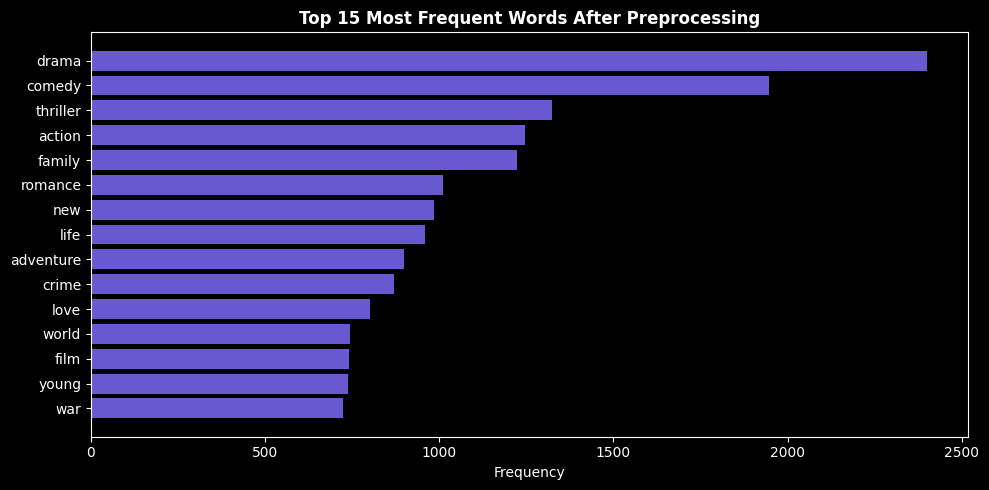

In [5]:
import re

# Load raw combined text from processed file for comparison
all_clean_words = ' '.join(df['clean_text'].fillna('')).split()

# Simulate 'before cleaning' by just lowercasing
raw_sample = ' '.join(df['clean_text'].fillna('').sample(200, random_state=42)).lower()
raw_words = re.sub(r'[^a-z\s]', '', raw_sample).split()

top_clean = Counter(all_clean_words).most_common(15)

fig, ax = plt.subplots(figsize=(10, 5))
words, counts = zip(*top_clean)
ax.barh(list(words), list(counts), color='#7c6af7', alpha=0.85)
ax.set_title('Top 15 Most Frequent Words After Preprocessing', fontweight='bold')
ax.set_xlabel('Frequency')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/word_frequency_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Text Length Distribution After Cleaning

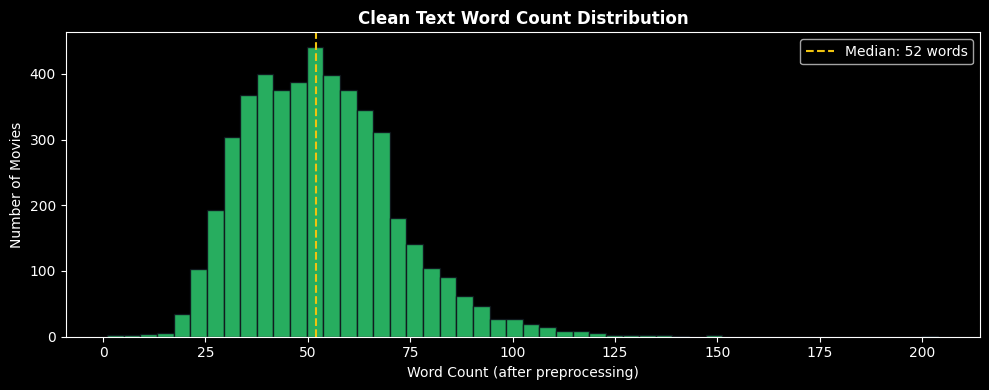

count    4803.000000
mean       53.189881
std        18.561664
min         1.000000
25%        39.000000
50%        52.000000
75%        64.000000
max       204.000000
Name: clean_word_count, dtype: float64


In [6]:
df['clean_word_count'] = df['clean_text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['clean_word_count'].dropna(), bins=50, color='#2ecc71', edgecolor='#0f0f1a', alpha=0.85)
ax.axvline(df['clean_word_count'].median(), color='#f1c40f', linestyle='--',
           label=f"Median: {df['clean_word_count'].median():.0f} words")
ax.set_title('Clean Text Word Count Distribution', fontweight='bold')
ax.set_xlabel('Word Count (after preprocessing)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/clean_text_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['clean_word_count'].describe())

## 6. Inspect Individual Movie Representations

Each movie is now represented as a bag of meaningful content words, ready for embedding.

In [7]:
for _, row in df.sample(4, random_state=7).iterrows():
    print(f"Movie  : {row['title']}")
    print(f"Genres : {row['genres']}")
    print(f"Clean  : {row['clean_text'][:200]}")
    print()

Movie  : Rocket Singh: Salesman of the Year
Genres : Drama Comedy Romance
Clean  : drama comedy romance ambition bollywood business india struggling career rocket singh salesman year sometimes thoughtless sometimes thoughtful story fresh graduate trying find balance maddening demand

Movie  : Jack Ryan: Shadow Recruit
Genres : Action Drama Thriller
Clean  : action drama thriller london england corruption cia terrorist sniper explosive intelligence russia murder conspiracy surveillance agent jack ryan us marine rehab analyst jack ryan young covert cia ana

Movie  : The Hotel New Hampshire
Genres : Comedy Drama
Clean  : comedy drama suicide bomb prostitute rape sex hotel based novel terrorist fight nudity satire film talks family weathers sorts disasters keeps going spite noted wonderful assortment oddball characters

Movie  : Resident Evil: Afterlife
Genres : Action Adventure Horror Science Fiction
Clean  : action adventure horror science fiction postapocalyptic dystopia undead biohazar

## Summary

| Step | Method | Library |
|------|--------|----------|
| Combine fields | genres + keywords + overview + cast | pandas |
| Lowercase | `.lower()` | Python built-in |
| Remove punctuation | `re.sub(r'[^a-z\s]', '')` | re (regex) |
| Remove stopwords | NLTK English stopword list (179 words) | NLTK |
| Tokenise | `.split()` | Python built-in |

The output is `data/processed/movies_processed.csv` with a `clean_text` column — the input to all subsequent modelling steps.